# OpenCV

In [1]:
from random import random

import numpy as np
import cv2
from numpy.ma.core import append

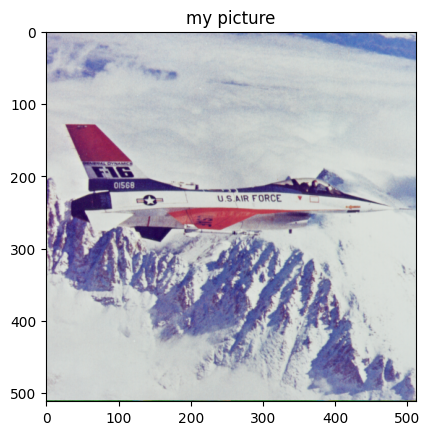

In [4]:
from matplotlib import pyplot as plt
from skimage import io

image = io.imread('https://i.postimg.cc/ZR7njqz4/4-2-05.png')

plt.imshow(image)
plt.title('my picture')
plt.show()


Dostęp do wartości kanałów piksela można uzyskać przez jego współrzędne (wiersz, kolumna), dla obrazów kolorowych (przechowywanych w zapisie BGR lub RGB) wynikiem będzie 3-elementowa tablica. Dla obrazów w skali szarości wynikiem operacji będzie zaś pojedyncza wartość:

In [5]:
px = image[200, 200]
print(px)

[203 208 205]


In [6]:
blue = image[200, 200, 0] #pobieramy wartość jednego kanału
print(blue)

203


Użycie operatora zakresu : pozwala na dostęp do określonego zestawu sąsiednich wierszy i kolumn obrazu, w celu wydzielenia tak zwanego obszaru zainteresowania (ang. Region of Interest, ROI). Wydzielanie mniejszego obszaru z obrazu i późniejsze dokonywanie operacji na tym obszarze często występuje w zagadnieniach związanych z widzeniem komputerowym. Przykład wydzielenia ROI i wklejenia go w innym miejscu obrazu:

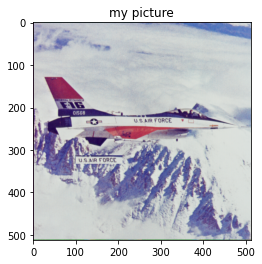

In [ ]:
roi = image[220:240, 230:340]
image[313:333, 100:210] = roi
plt.imshow(image)
plt.title('my picture')
plt.show()

#Zadania:

**Zadanie**: Ze strony domowej prowadzącego pobierz logo Uniwersytetu Rzeszowskiego. Za pomocą Pythona i OpenCV utwórz biały obraz o rozmiarach 1000 x 1000 px, a następnie wklej wielokrotnie kopie loga obok siebie, jedna po drugiej.

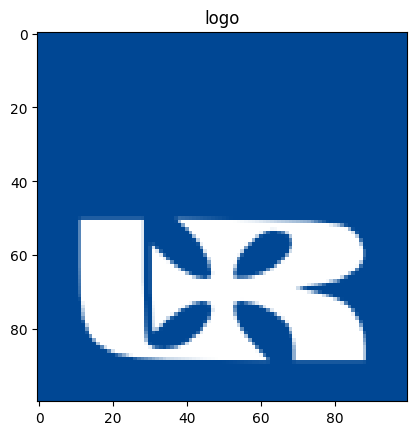

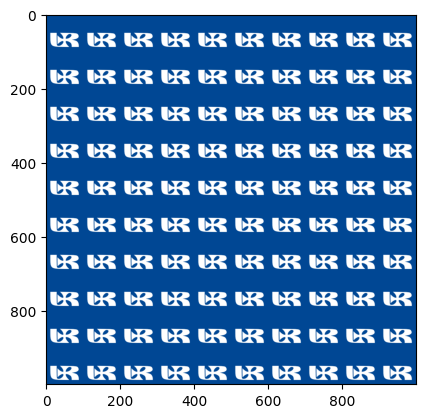

In [21]:
#rozwiązanie:
from skimage import io
import matplotlib.pyplot as plt

logo = io.imread('http://fenix.univ.rzeszow.pl/~mkepski/logoUR.png')
plt.imshow(logo)
plt.title('logo')
plt.show()

img = np.ones((1000, 1000, 4), dtype="uint8") * 255

h, w, _ = logo.shape

for i in range(0, 1000, h):
    for y in range(0, 1000, w):
        if y + w <= 1000 and i + h <= 1000:
            img[i:i+h, y:y+w] = logo


plt.imshow(img)
plt.show()



**Zadanie**: Podobnie jak w zadaniu wyżej, utwórz biały obraz o rozmiarach 1000 x 1000 px.  Wylosuj 50 współrzędnych (x,y) (skorzystaj z dokumentacji dot. generowania liczb pseudolosowych w Pythonie), które określać będą pozycję górnego lewego rogu wklejanego loga na białym obrazie. Wklej logo 50 razy dla wylosowanych współrzędnych. W zadaniu zadbaj o zakresy liczb, tak, aby nie próbować wkleić fragmentu obszaru ROI (będącego logiem) poza obraz.


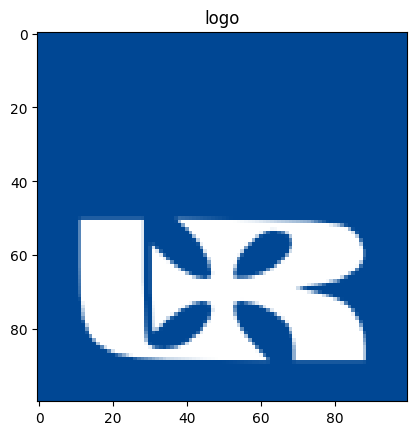

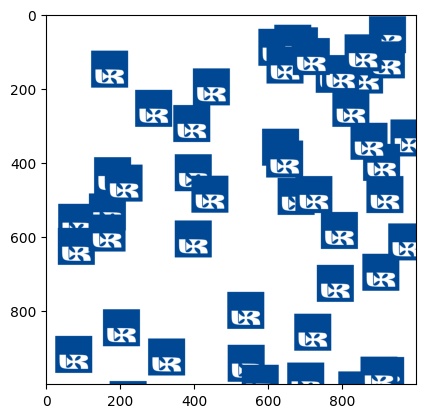

In [28]:
#rozwiązanie:
from skimage import io
import matplotlib.pyplot as plt
import random

logo = io.imread('http://fenix.univ.rzeszow.pl/~mkepski/logoUR.png')
plt.imshow(logo)
plt.title('logo')
plt.show()

bialy_obraz = np.ones((1000,1000,4), dtype="uint8") * 255

h, w, _ = np.shape(bialy_obraz)

x = [random.randint(0,999) for _ in range(50)]
y = [random.randint(0,999) for _ in range(50)]

logo_h, logo_w = logo.shape[:2]

for i in range(50):
    y_start, x_start = y[i], x[i]
    y_end, x_end = min(y_start + logo_h, 1000), min(x_start + logo_w, 1000)
    logo_slice = logo[:y_end - y_start, :x_end - x_start]
    bialy_obraz[y_start:y_end, x_start:x_end] = logo_slice

plt.imshow(bialy_obraz)
plt.show()




**Zadanie**: Przekonwertuj używany wyżej obraz ```jet``` do skali szarości i dokonaj operacji wyrównania histogramu. Możesz skorzystać z: https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html

In [ ]:
#rozwiązanie:

# Filtracja liniowa

Najpopularniejszą operacją kontekstową na obrazie jest filtracja liniowa, w której wartość piksela jest sumą ważoną pikseli obrazu wejściowego:

<img src="https://i.postimg.cc/9fR20WMk/img-corr.png" alt="Correlation on image" width="292px"/>

Wartości wag *h(k,l)* nazywane są często kernelem bądź wagami filtra. Powyższą operację nazywamy korelacją obrazu z filtrem. Częściej wykorzystywaną operacją jest **konwolucja dyskretna**:

<img src="https://i.postimg.cc/nc46h3Jq/img-conv.png" alt="Convolution on image" width="450px"/>

w której stosujemy inną kolejność wag filtra, co dobrze obrazuje poniższy rysunek:

<img src="https://i.postimg.cc/tRfjJ9gP/img-conv-viz.png" alt="Convolution on image" width="450px"/>

Operacja filtracji polega na "przykładaniu" filtra w kolejnych pikselach obrazu wejściowego i obliczaniu wartości piskela obrazu wyjściowego na podstawie operacji konwolucji:

<img src="https://i.postimg.cc/YC2fPLcB/img-conv-example.png" alt="Convolution on image" width="450px"/>


Najprostszą operację filtracji obrazu z wykorzystaniem filtra uśredniającego (averaging filter) można zrealizować za pomocą funkcji ```cv2.blur()``` lub ```cv2.boxFilter```.  ```cv2.blur(src, ksize)``` dokonuje operacji konwolucji obrazu z filtrem uśredniającym K o rozmiarze ```ksize```, parametr definiujący rozmiar filtra jest dwuelementową krotką. Filtrację taką możemy w OpenCV zrealizować następująco:




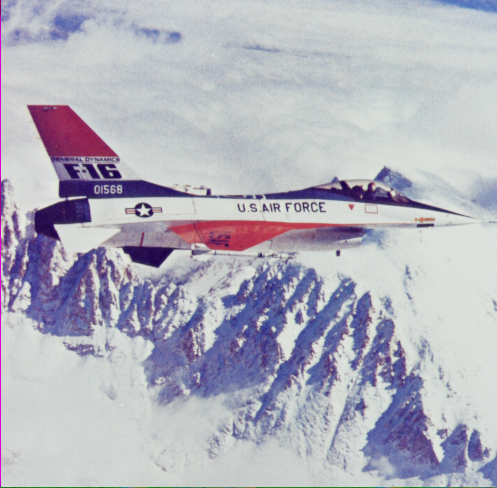

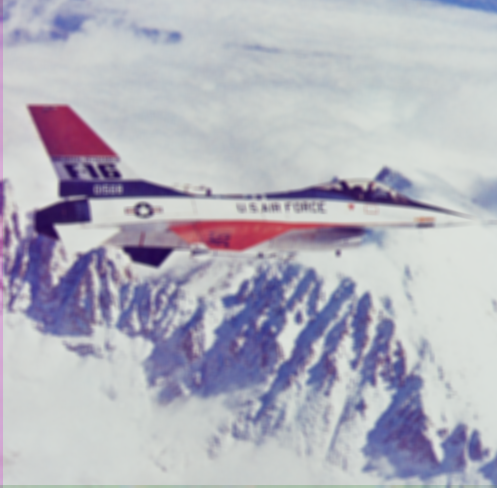

In [ ]:
import cv2
from matplotlib import pyplot as plt
from skimage import io
import numpy as np

# potrzebne do wyświetlania obrazów w oryginalnym rozmiarze
default_dpi = plt.rcParams["figure.dpi"]

image = io.imread('https://i.postimg.cc/ZR7njqz4/4-2-05.png')

image_figsize = (image.shape[0] / default_dpi + 1, image.shape[1]/ default_dpi + 1)

empty = np.zeros(image.shape)
plt.figure(figsize=image_figsize)
plt.figimage(image)
plt.show()

filtered = cv2.blur(image, (5,5))

plt.figure(figsize=image_figsize)
plt.figimage(filtered)
plt.show()


**Zadanie**: Zmień (zwiększ) rozmiar filtra uśredniającego i zaobserwuj rezultat operacji na obrazie:

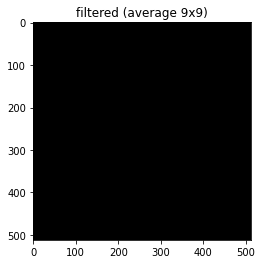

In [ ]:
#rozwiązanie:

filtered = empty # TODO: zastąp pusty obraz wywołaniem funkcji cv2.blur z maską o rozmiarze 9x9

plt.imshow(filtered)
plt.title('filtered (average 9x9)')
plt.show()


Szczególnym przypadkiem filtracji liniowej jest filtracja gaussowska, w której wykorzystywana jest maska filtra o zróżnicowanych wagach pochodzących z rozkładu Gaussa. Idea wykorzystania takiego filtra opiera się na założeniu, że piksele w najbliższym sąsiedztwie filtrowanego piksela niosą najwięcej informacji o jego prawdopodobnym kolorze, a im bardziej oddalone piksele, tym mniejszy powinny mieć wpływ na wynik filtracji (mniejsze wagi). Typowa maska filtra Gaussa prezentuje się następująco:

<img src="https://i.postimg.cc/W3fCtP5p/gauss-mask.png" alt="Convolution on image" width="200px"/>

**Zadanie**: Wykorzystaj do flitracji funkcję ```cv.GaussianBlur()``` i porównaj jej działanie z filtrem uśredniającym dla różnych (rosnących) rozmiarów filtra.



**Zadanie**: Dodaj szum gaussa do obrazu: wylosuj liczby z rozkładu normalnego (używając odpowiednich funkcji) a następnie dodaj szum do wartości pikseli obrazu (korzystając z funkcji ```add``` OpenCV). Dokonaj filtracji obrazów zaszumionych filtrami uśredniającymi i gaussowskimi. Eksperymentuj z siłą szumu i rozmiarem maski filtra. Które metody filtracji dają najlepsze rezultaty?